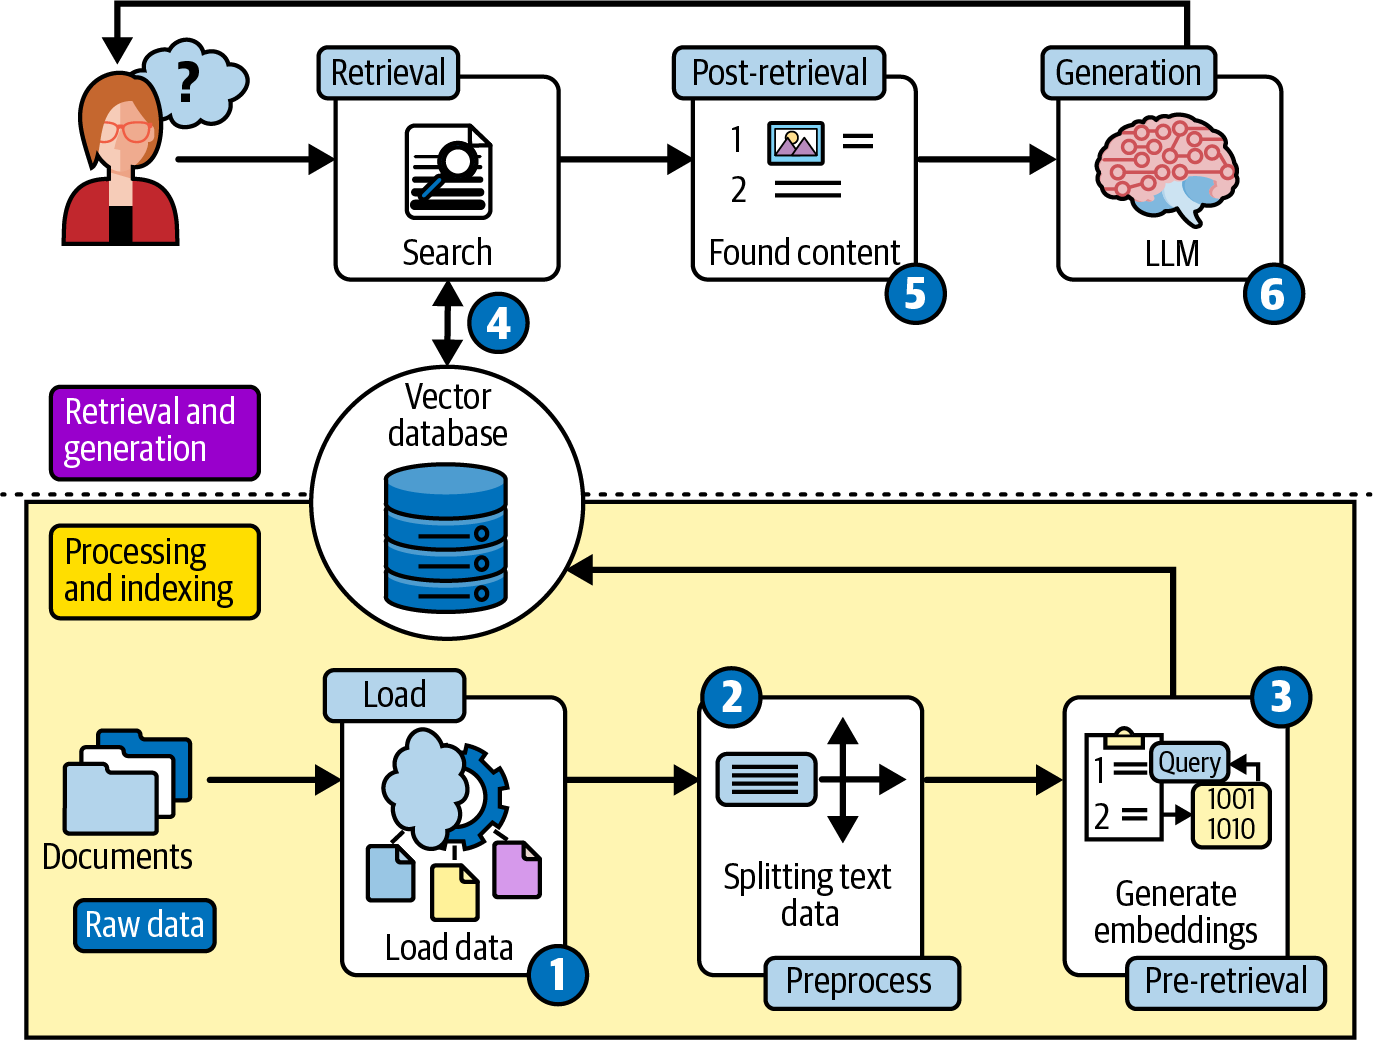

In [3]:
from IPython.display import Image, display
display(Image(filename="../images/7.png", width=500, height=500))

#### 1.Loading Word Files in Python

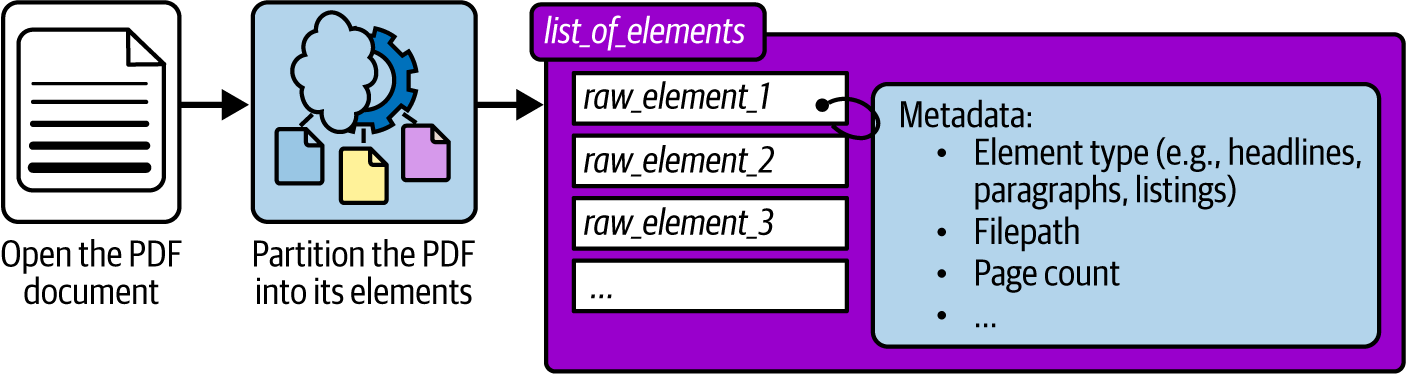

In [3]:
from IPython.display import Image, display
display(Image(filename="../images/8.png", width=500, height=500))

In [ ]:
pip install python-docx unstructured pandas

In [ ]:
import os
from docx import Document

file_path = (
    "../datasets/word_files/"
    "2023_Jan_7_Feature_Engineering_Techniques.docx"
)

doc = Document(file_path)

text = []
for paragraph in doc.paragraphs:
    text.append(paragraph.text)

full_text = "\n".join(text)

In [ ]:
from unstructured.partition.docx import partition_docx
import os
import pandas as pd

elements = partition_docx(filename=file_path)

list_of_elements = []

for element in elements:
    element_dict = {
        "element_id": element.id,
        "file_path": file_path,
        "category": element.category,
        # e.g., "Title", "NarrativeText", "ListItem"
        "text": element.text,
        "last_modified": element.metadata.last_modified,
    }

    list_of_elements.append(element_dict)

elements_df = pd.DataFrame(list_of_elements)

Most loading libraries like Unstructured or Docling are especially mature in loading PDFs. When dealing with various file formats, convert all to PDF first. Recipe 3.10 covers PDF loading and processing approaches.

#### 2. Loading PDF Files

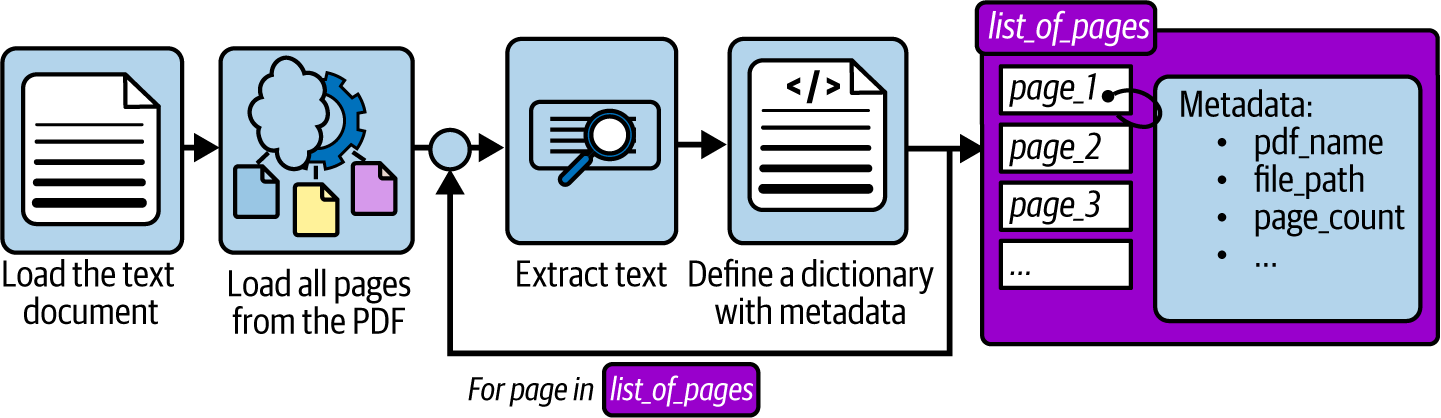

In [4]:
display(Image(filename="../images/9.png", width=500, height=500))

In [ ]:
import PyPDF2
import os
import pandas as pd

file_path = (
    "../datasets/pdf_files/"
    "2023_Jan_7_Feature_Engineering_Techniques.pdf"
)

with open(file_path, "rb") as file:
    reader = PyPDF2.PdfReader(file)

    list_of_pages = []
    page_counter = 1

    for page in reader.pages:
        page_dict = {
            "file_name": reader.metadata.get("/Title"),
            "producer": reader.metadata.get("/Producer"),
            "page_number": page_counter,
            "text": page.extract_text(),
            "images": page.images,
        }
    list_of_pages.append(page_dict)

    page_counter += 1

pages_df = pd.DataFrame(list_of_pages)

#### 3. Loading and Handling Tabular Data from Excel and CSV Files

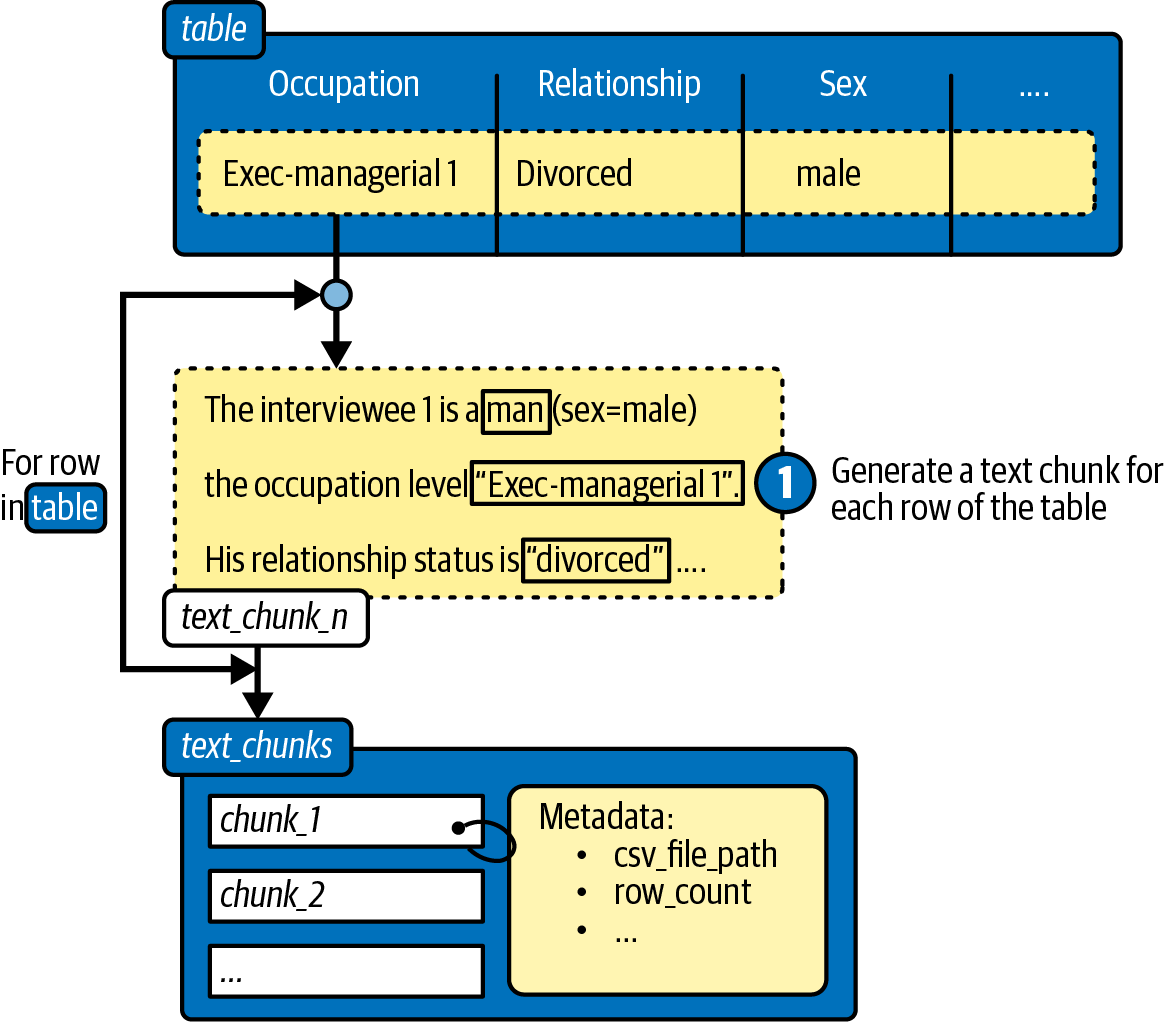

In [5]:
display(Image(filename="../images/10.png", width=500, height=500))

In [ ]:
pip install openpyxl pandas

In [ ]:
import os
import pandas as pd

file_path = "../datasets/csv_files/census-income.xlsx"
df_excel = pd.read_excel(io=file_path)


def create_text_description_of_row(row):
    row["text_description"] = (
        f"""The candidate {row['age']} years old is working in the
            {row['workclass']} sector. The candidate was born in
            {row['native-country']}, is {row['marital-status']}
            and has a {row['relationship']} relationship.
            The candidate has a {row['education']} degree and is
            working as a {row['occupation']}. The income of the
            candidate is {row['income']}."""
    )

    return row


# Apply the function create_text_description_of_row
# to each row of the DataFrame
df_extended = df_excel.apply(create_text_description_of_row, axis=1)

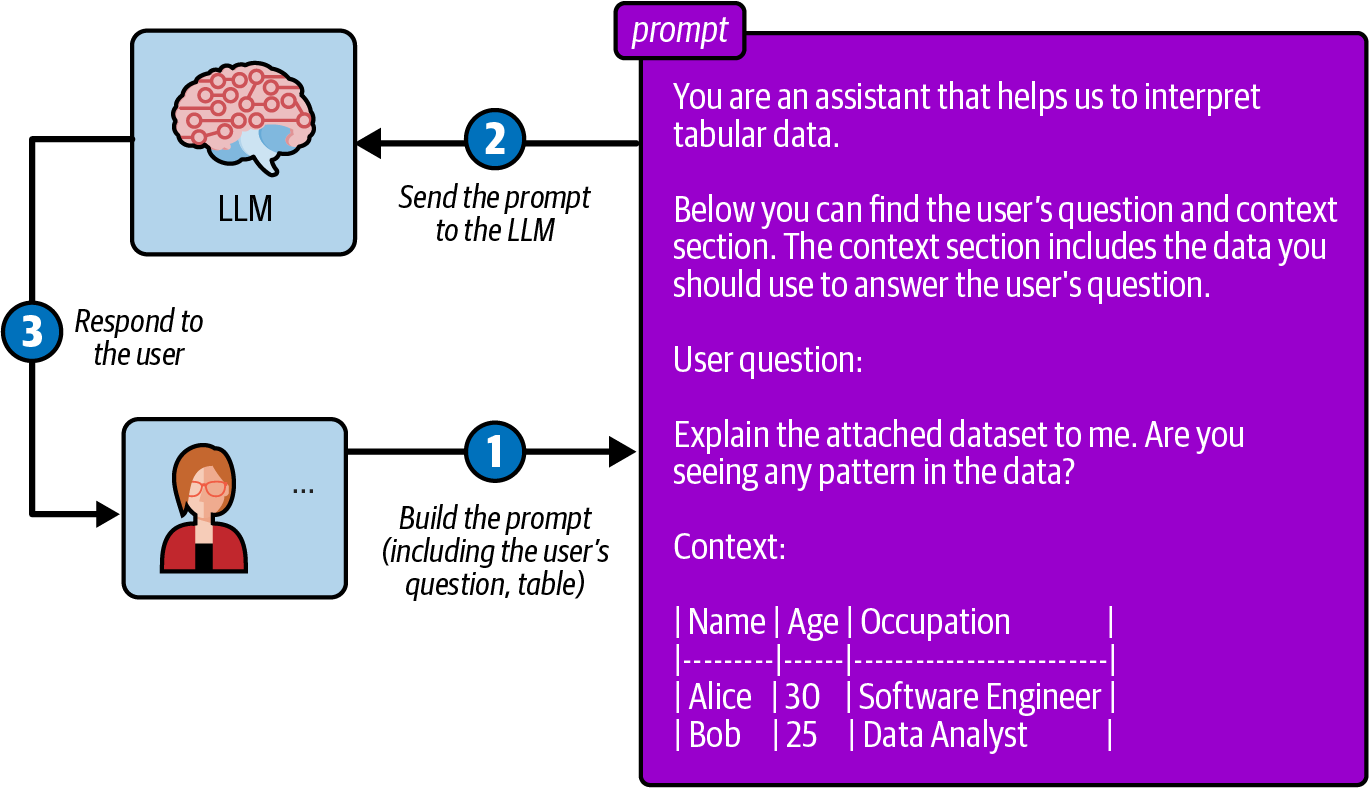

In [6]:
display(Image(filename="../images/11.png", width=500, height=500))

#### Option 3: Using text-to-SQL for complex queries

For complex analytical queries or large datasets, the text-to-SQL approach is the most powerful option. The tabular data is uploaded to a SQL database. When a user asks a question, an LLM analyzes the table schema and the user’s question to generate an appropriate SQL query. The query results are then interpreted by the LLM to produce a natural language answer.

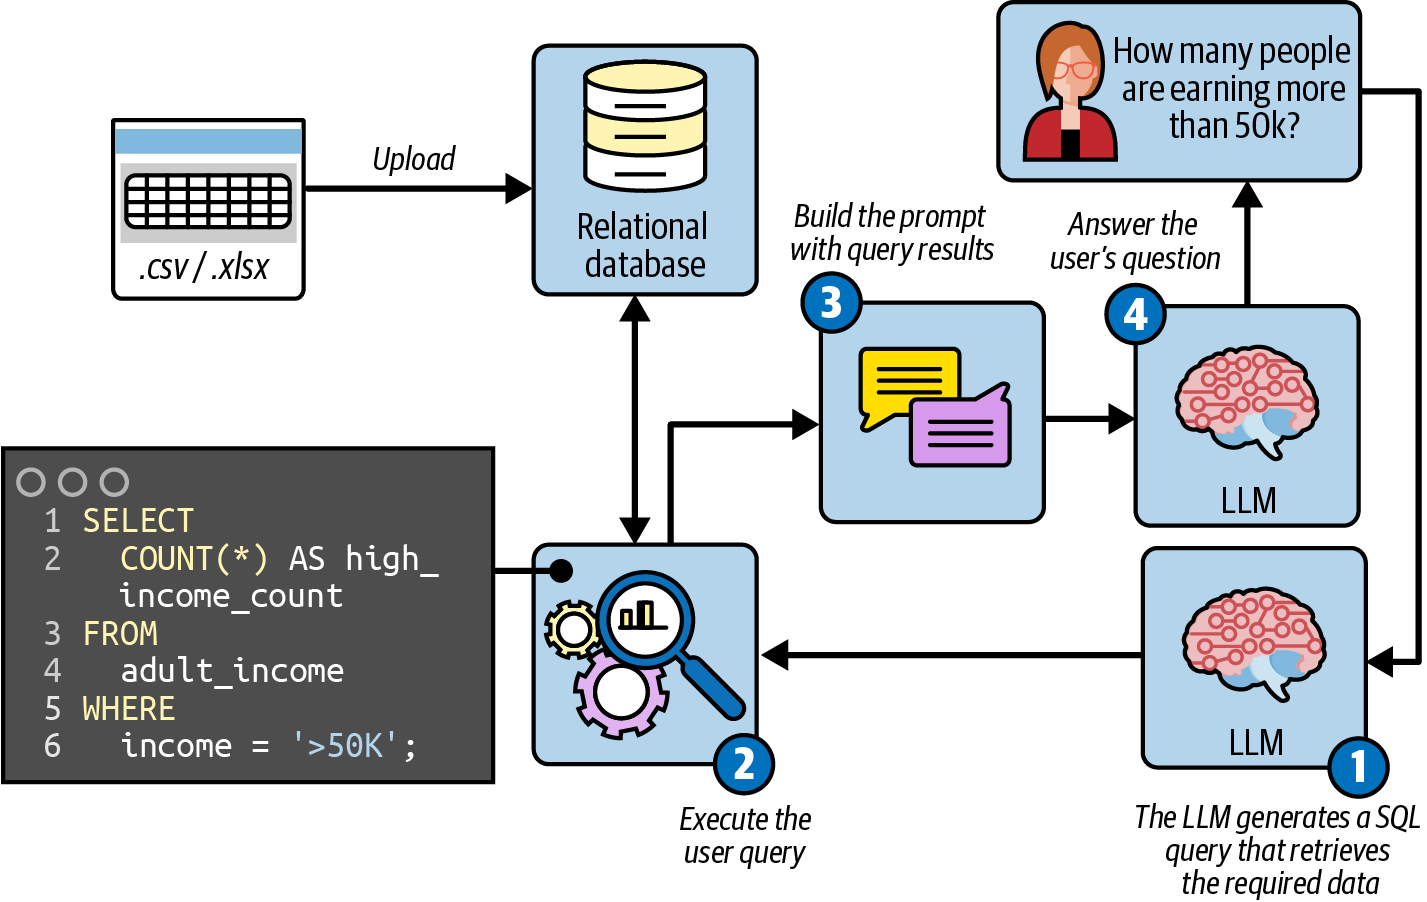

In [7]:
display(Image(filename="../images/12.png", width=500, height=500))

### Loading Structured Data from a PostgreSQL Database

In [ ]:
pip install SQLAlchemy psycopg2-binary pandas python-dotenv

In [ ]:
import os
import pandas as pd
from sqlalchemy import create_engine

connection_string = (
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)
engine = create_engine(connection_string)

with engine.connect() as connection:
    query = """SELECT * FROM categories ORDER BY category_id ASC """
    result = pd.read_sql(query, connection)
    print(result)

#### Loading Audio Files via Speech-to-Text Models

In [ ]:
import os
from openai import OpenAI

audio_file_path = "../datasets/audio_files/harvard.wav"

# Initialize the OpenAI client with your API key
client = OpenAI()

with open(audio_file_path, "rb") as audio_file:
    transcription = client.audio.transcriptions.create(
        model="whisper-1", file=audio_file
    )

### Extracting Text from Images and PDFs via Tesseract OCR

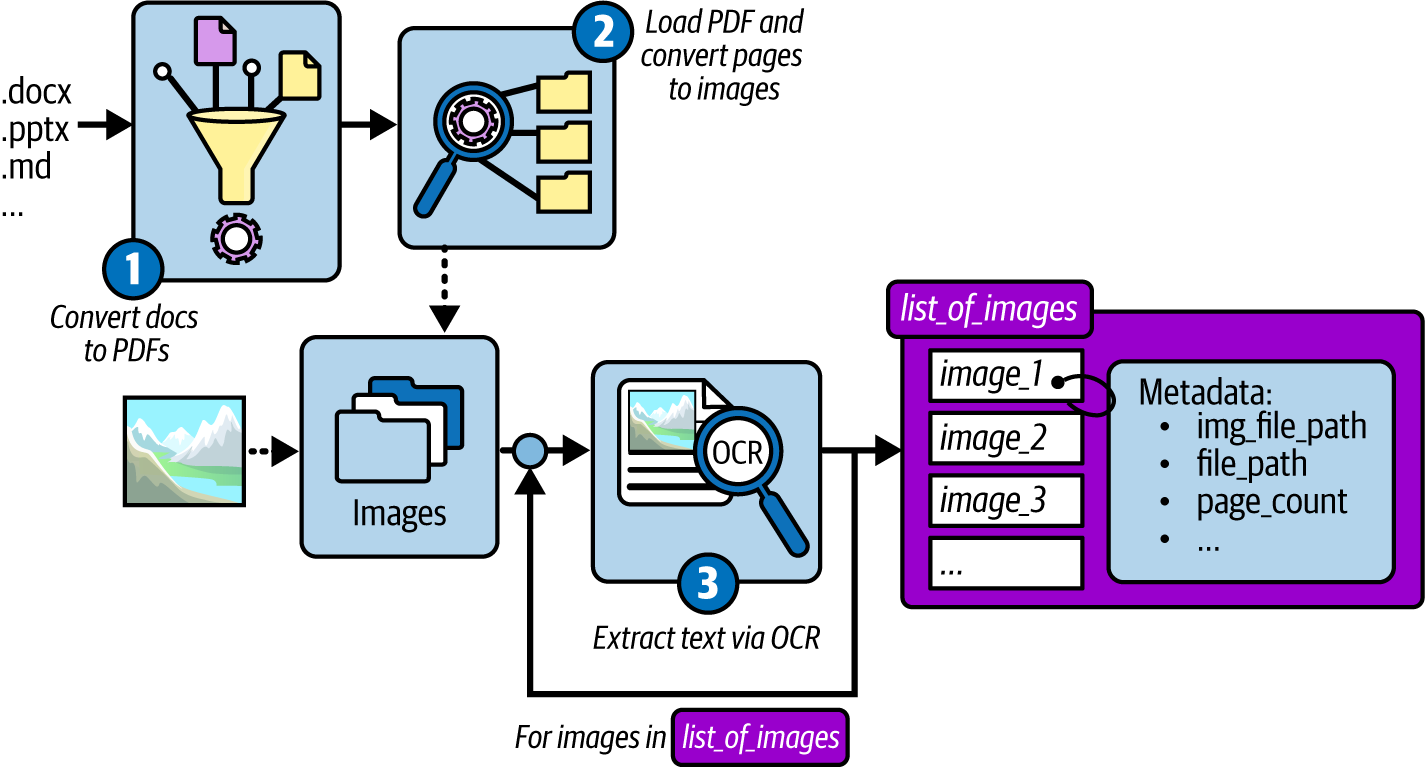

In [4]:
display(Image(filename="../images/13.png", width=500, height=500))

In [ ]:
pip install pdf2image pytesseract pillow

In [ ]:
import os
from pdf2image import convert_from_path
from PIL import Image
import pytesseract

image = Image.open(
    fp="../datasets/images/example_finance_reporting_slide.png"
)

text = pytesseract.image_to_string(image)

In [ ]:
import os
from pdf2image import convert_from_path
from PIL import Image
import pytesseract

file_path = (
    "../datasets/pdf_files/"
    "2023_Jan_7_Feature_Engineering_Techniques.pdf"
)

images = convert_from_path(pdf_path=file_path)

text = []
for i, image in enumerate(images):
    page_text = pytesseract.image_to_string(image)
    text.append(page_text)

#### Extracting Text from Images via Multimodal Models

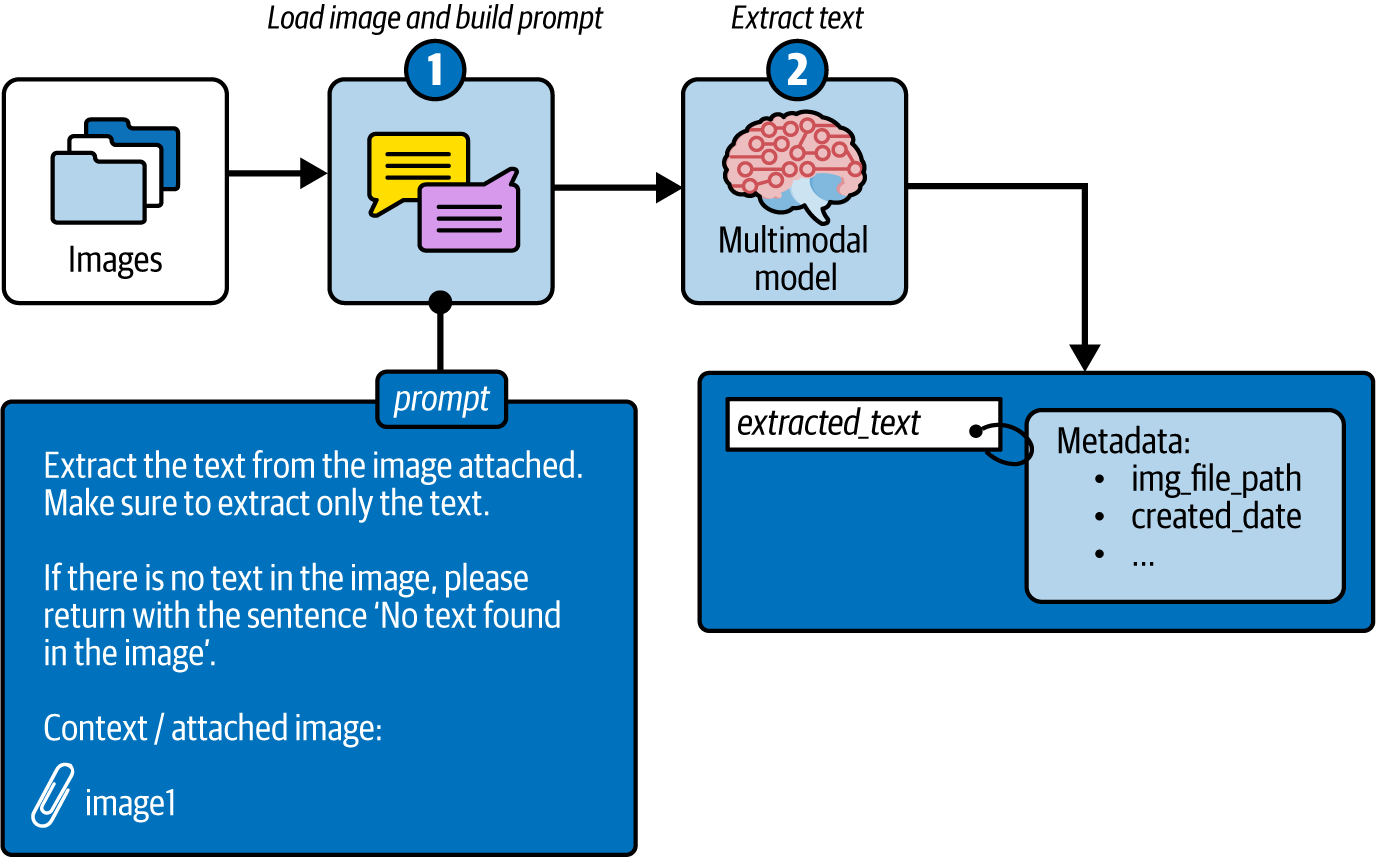

In [5]:
display(Image(filename="../images/14.png", width=500, height=500))

In [ ]:
import os
import base64
from openai import OpenAI

png_file_path = "../datasets/images/example_finance_reporting_slide.png"

# Initialize the OpenAI client
client = OpenAI()

with open(png_file_path, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode("utf-8")

    prompt = (
        "Extract the text from the image attached. Make sure to only "
        "extract only the text. If there is no text in the image, "
        "please return with the sentence 'No text found in the image."
    )
    response = client.chat.completions.create(
        model="gpt-5.2",  # Define the model to use
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": (
                                f"data:image/jpeg;base64,"
                                f"{base64_image}"
                            ),
                        },
                    },
                ],
            }
        ],
        max_tokens=500,
    )
content = response.choices[0].message.content